In [18]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt


In [19]:
!pip install scikit-learn

In [20]:
import os
print(os.getcwd())

/home/ravi-kumar-pal/ML Internship/Machine Learning Internship MIP-ML-07/Project 1 Gold price prediction/gold_price_arima


In [21]:
df = pd.read_csv('goldstock.csv')

In [22]:
df.head()

,Unnamed: 0,Date,Close,Volume,Open,High,Low
0,0,2024-01-19,2029.3,166078.0,2027.4,2041.9,2022.2
1,1,2024-01-18,2021.6,167013.0,2009.1,2025.6,2007.7
2,2,2024-01-17,2006.5,245194.0,2031.7,2036.1,2004.6
3,3,2024-01-16,2030.2,277995.0,2053.4,2062.8,2027.6
4,4,2024-01-12,2051.6,250946.0,2033.2,2067.3,2033.1


In [23]:
df = df.drop(columns=['Unnamed: 0'])

In [24]:
df['Date'] = pd.to_datetime(df['Date'])

In [25]:
df.head()


,Date,Close,Volume,Open,High,Low
0,2024-01-19,2029.3,166078.0,2027.4,2041.9,2022.2
1,2024-01-18,2021.6,167013.0,2009.1,2025.6,2007.7
2,2024-01-17,2006.5,245194.0,2031.7,2036.1,2004.6
3,2024-01-16,2030.2,277995.0,2053.4,2062.8,2027.6
4,2024-01-12,2051.6,250946.0,2033.2,2067.3,2033.1


In [26]:
df.set_index('Date', inplace=True)

In [27]:
df.sort_index(inplace=True)

In [28]:
df.head()

,Close,Volume,Open,High,Low
Date,,,,,
2014-01-22,1238.6,80262.0,1240.5,1243.5,1235.5
2014-01-23,1262.5,41697.0,1235.1,1267.1,1230.8
2014-01-24,1264.5,34998.0,1264.3,1273.2,1256.9
2014-01-27,1263.5,63419.0,1269.9,1280.1,1252.0
2014-01-28,1250.5,81426.0,1254.9,1261.9,1248.0


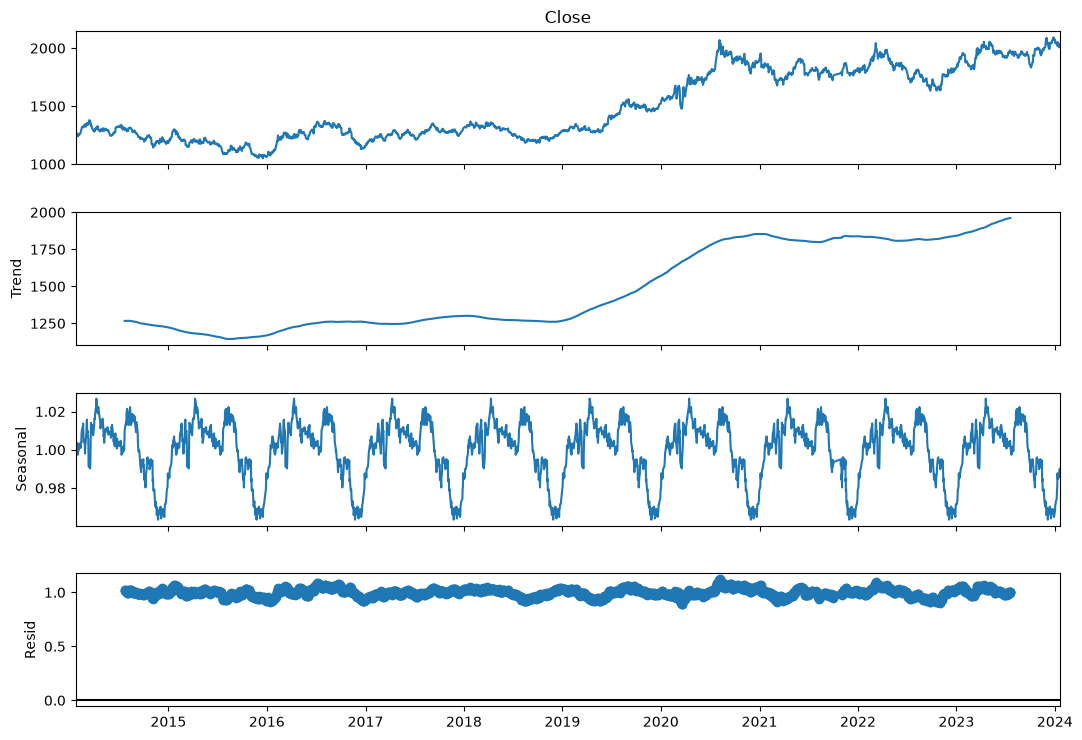

In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose 

decomposition = seasonal_decompose(df['Close'], model='multiplicative', period=252)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

In [1]:
pip install prophet

  Using cached prophet-1.3.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.5 kB)
  Using cached cmdstanpy-1.3.0-py3-none-any.whl.metadata (4.2 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 278.3 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 410.9 kB/s eta 0:00:00 0:00:01
  Using cached importlib_resources-7.1.0-py3-none-any.whl.metadata (4.0 kB)
  Using cached stanio-0.5.1-py3-none-any.whl.metadata (1.6 kB)
Using cached prophet-1.3.0-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (12.1 MB)
Using cached cmdstanpy-1.3.0-py3-none-any.whl (99 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.6/676.6 kB 4.7 MB/s eta 0:00:00:00:0100:01
Using cached importlib_resources-7.1.0-py3-none-any.whl (37 kB)
Using cached stanio-0.5.1-py3-none-any.whl (8.1 kB)
Note: you may need to restart the kernel to use updated packages.


21:44:03 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet model...


21:44:04 - cmdstanpy - INFO - Chain [1] done processing


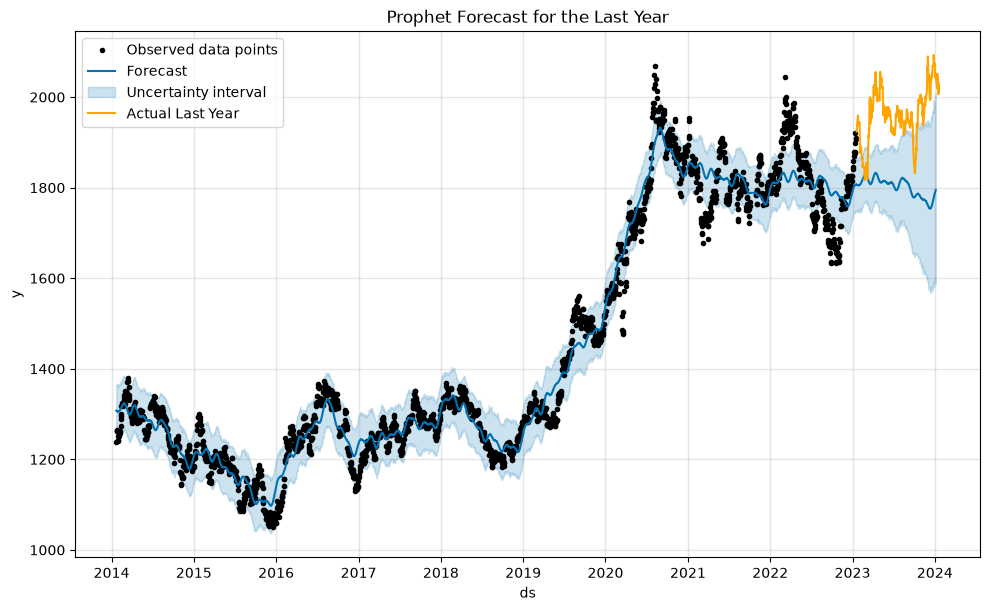

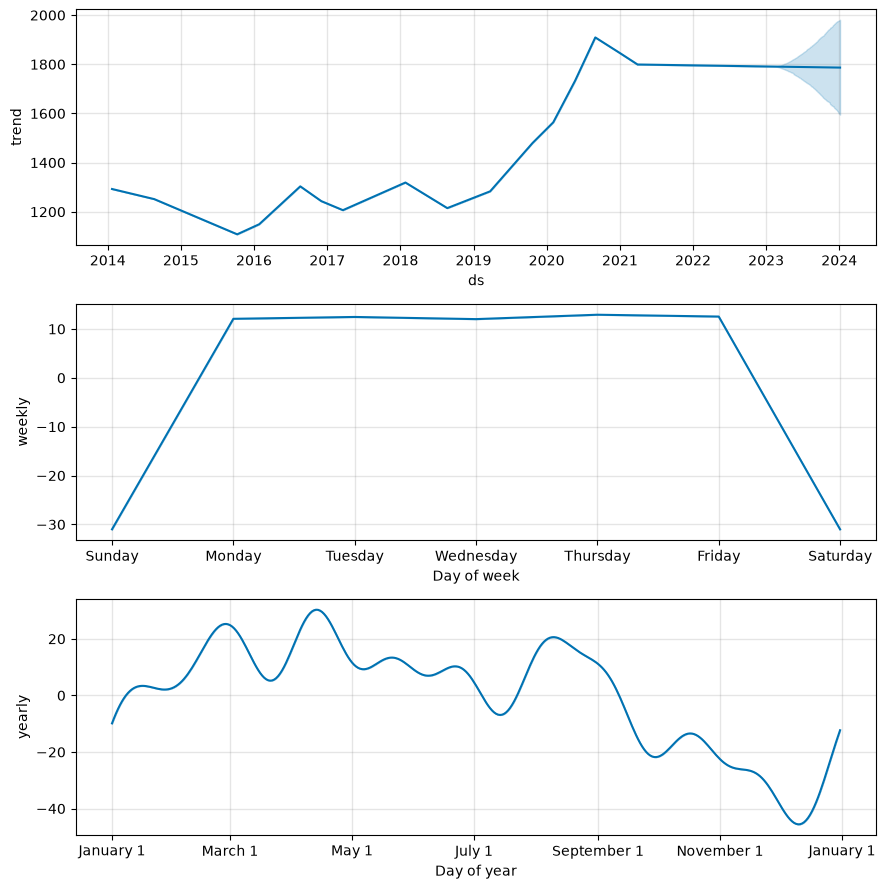


--- Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): $175.00
Mean Absolute Error (MAE): $160.53
Mean Absolute Percentage Error (MAPE): 8.09%


In [32]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# NEW FIX 1: Tell Matplotlib how to handle pandas datetime formats
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Prophet requires columns to be named exactly 'ds' (dates) and 'y' (values)
prophet_df = df.reset_index()[['Date', 'Close']]
prophet_df.columns = ['ds', 'y']

# NEW FIX 2: Force the dates into a standard format that Matplotlib understands
prophet_df['ds'] = pd.to_datetime(prophet_df['ds']).dt.tz_localize(None)

# 1. Split train and test
test_size = 252
train_data = prophet_df.iloc[:-test_size]
test_data = prophet_df.iloc[-test_size:]

# 2. Train the Prophet model
print("Training Prophet model...")
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(train_data)

# 3. Predict the last year
future = model.make_future_dataframe(periods=test_size, freq='B') # 'B' for business days
forecast = model.predict(future)

# 4. Plot the results
fig = model.plot(forecast)
plt.plot(test_data['ds'].values, test_data['y'].values, color='orange', label='Actual Last Year')
plt.legend()
plt.title("Prophet Forecast for the Last Year")
plt.show()

# 5. You can even see the trend and seasonal components exactly like your image!
fig2 = model.plot_components(forecast)
plt.show()

# 6. Check the error of the model (RMSE, MAE, MAPE)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Extract actual and predicted values for the test period
actuals = test_data['y'].values
predictions = forecast.iloc[-test_size:]['yhat'].values

# Calculate metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print("\n--- Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Finding best SARIMA parameters for monthly data... (This will be fast!)
Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=0.77 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1140.778, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1138.935, Time=0.11 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1138.709, Time=0.22 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1140.587, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=1136.711, Time=0.06 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=1138.709, Time=0.16 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=1138.634, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : AIC=1138.534, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1136.937, Time=0.04 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : AIC=1140.188, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[12]             : AIC=1136.068, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[12]

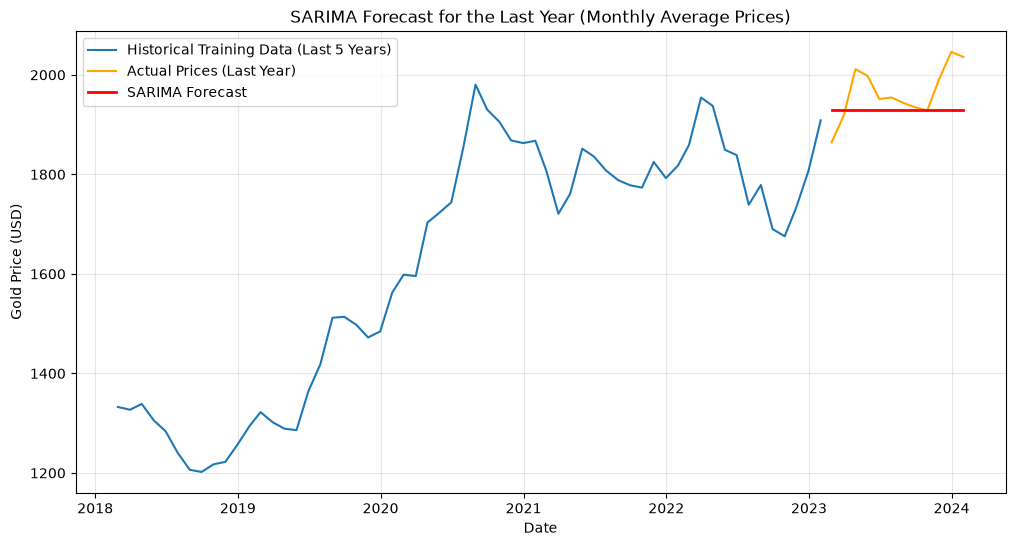

In [31]:
import pmdarima as pm
import matplotlib.pyplot as plt

# 1. Resample daily data to monthly data (average price per month)
# This solves the memory crash!
monthly_data = df['Close'].resample('ME').mean()

# 2. Isolate the last year (12 months) for testing
test_size = 12
train_data = monthly_data.iloc[:-test_size]
test_data = monthly_data.iloc[-test_size:]

# 3. Run Auto SARIMA with m=12
print("Finding best SARIMA parameters for monthly data... (This will be fast!)")
sarima_model = pm.auto_arima(train_data, 
                             seasonal=True, 
                             m=12,  # 12 months in a year
                             trace=True,
                             stepwise=True)

# 4. Predict the last 12 months
predictions = sarima_model.predict(n_periods=test_size)
predictions.index = test_data.index

# 5. Plot the actual vs predicted monthly prices
plt.figure(figsize=(12, 6))
plt.plot(train_data.index[-60:], train_data.iloc[-60:], label='Historical Training Data (Last 5 Years)')
plt.plot(test_data.index, test_data, label='Actual Prices (Last Year)', color='orange')
plt.plot(predictions.index, predictions, color='red', label='SARIMA Forecast', linewidth=2)

plt.title("SARIMA Forecast for the Last Year (Monthly Average Prices)")
plt.xlabel("Date")
plt.ylabel("Gold Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training Enhanced Prophet model...


21:46:46 - cmdstanpy - INFO - Chain [1] start processing
21:46:48 - cmdstanpy - INFO - Chain [1] done processing


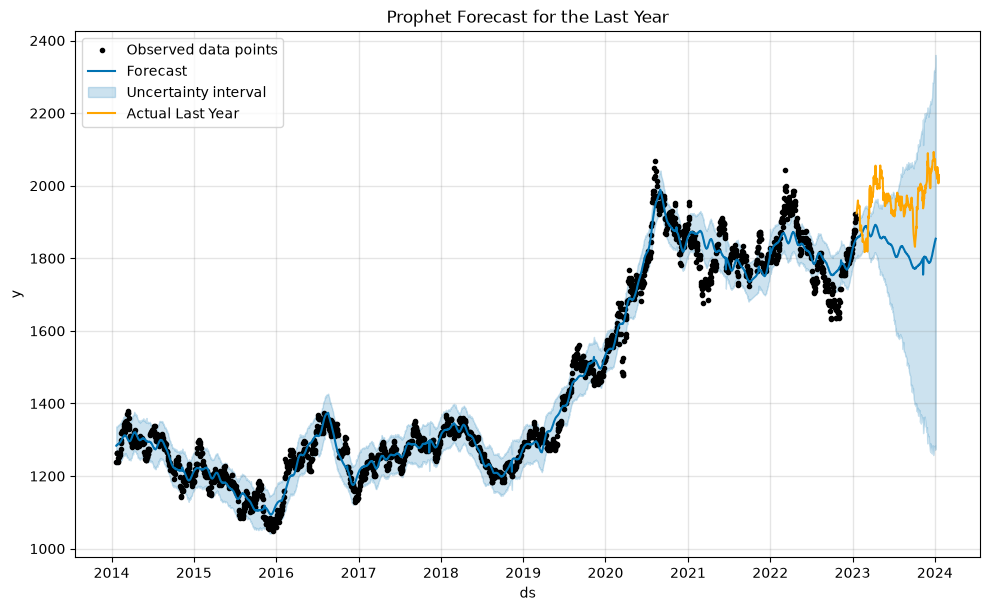

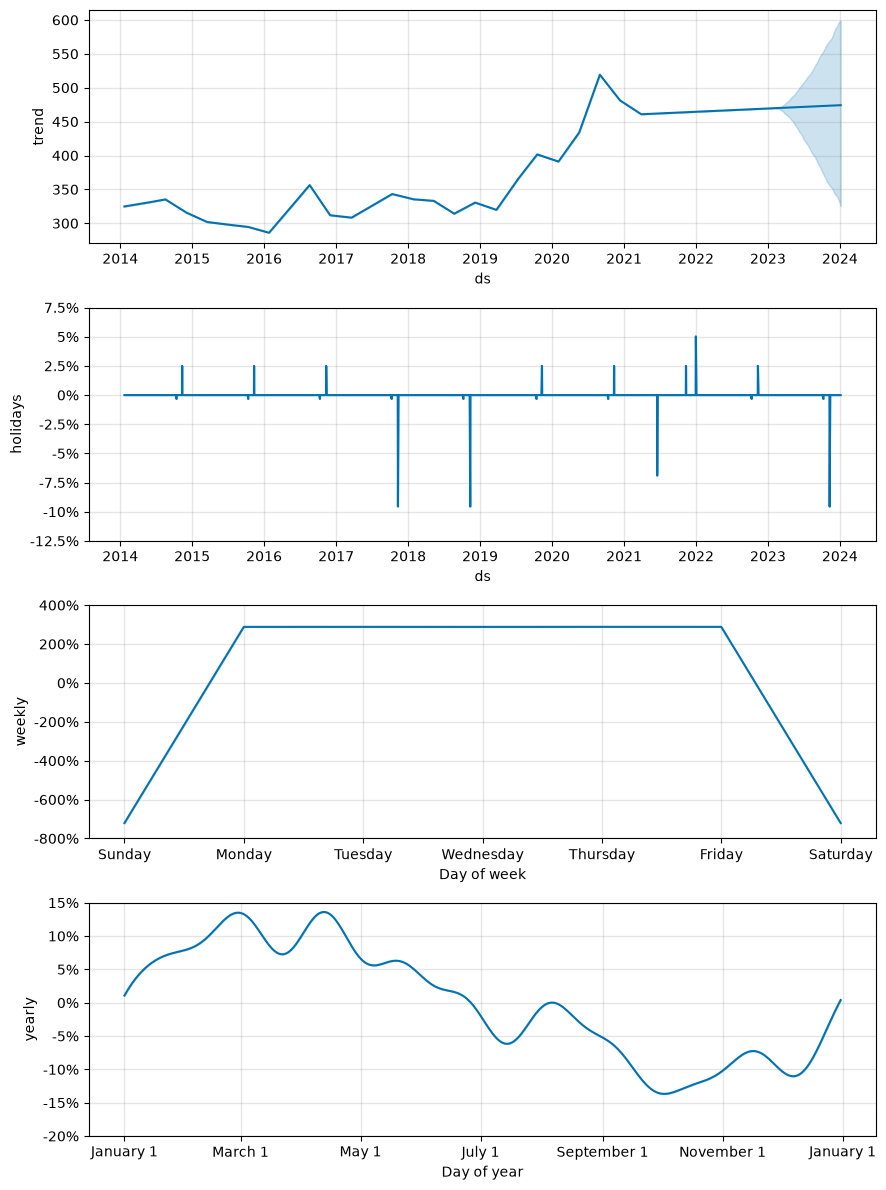


--- Model Evaluation Metrics ---
Root Mean Squared Error (RMSE): $149.86
Mean Absolute Error (MAE): $136.34
Mean Absolute Percentage Error (MAPE): 6.88%


In [33]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

# NEW FIX 1: Tell Matplotlib how to handle pandas datetime formats
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Prophet requires columns to be named exactly 'ds' (dates) and 'y' (values)
prophet_df = df.reset_index()[['Date', 'Close']]
prophet_df.columns = ['ds', 'y']

# NEW FIX 2: Force the dates into a standard format that Matplotlib understands
prophet_df['ds'] = pd.to_datetime(prophet_df['ds']).dt.tz_localize(None)

# 1. Split train and test
test_size = 252
train_data = prophet_df.iloc[:-test_size]
test_data = prophet_df.iloc[-test_size:]

# 2. Train the Enhanced Prophet model
print("Training Enhanced Prophet model...")
model = Prophet(
    yearly_seasonality=True, 
    daily_seasonality=False,
    seasonality_mode='multiplicative', # ENHANCEMENT 1: Scale waves with price
    changepoint_prior_scale=0.15       # ENHANCEMENT 2: Make trend more flexible
)

# ENHANCEMENT 3: Add US Holidays
model.add_country_holidays(country_name='US')

model.fit(train_data)

# 3. Predict the last year
future = model.make_future_dataframe(periods=test_size, freq='B') # 'B' for business days
forecast = model.predict(future)

# 4. Plot the results
fig = model.plot(forecast)
plt.plot(test_data['ds'].values, test_data['y'].values, color='orange', label='Actual Last Year')
plt.legend()
plt.title("Prophet Forecast for the Last Year")
plt.show()

# 5. You can even see the trend and seasonal components exactly like your image!
fig2 = model.plot_components(forecast)
plt.show()

# 6. Check the error of the model (RMSE, MAE, MAPE)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Extract actual and predicted values for the test period
actuals = test_data['y'].values
predictions = forecast.iloc[-test_size:]['yhat'].values

# Calculate metrics
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mae = mean_absolute_error(actuals, predictions)
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100

print("\n--- Model Evaluation Metrics ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:.2f}")
print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

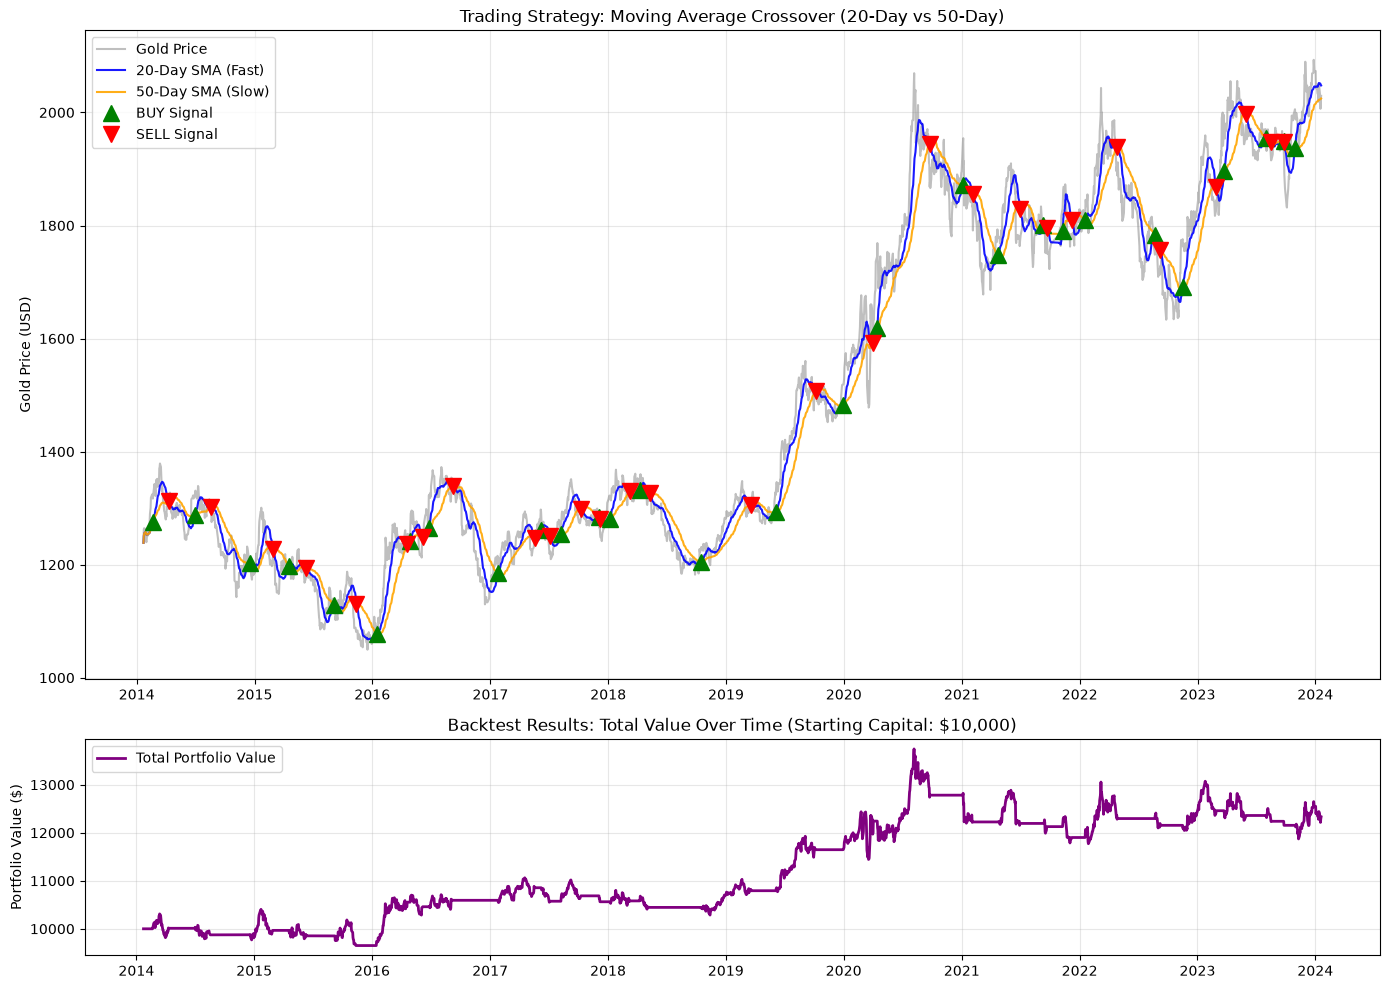

--- Trading Strategy Backtest Results ---
Initial Capital:      $10,000.00
Final Portfolio Value: $12,329.50
Total Profit/Loss:    $2,329.50
Return on Investment:  23.29%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Assuming 'df' is your original dataset that is already loaded and sorted by Date
# Let's create a fresh copy for our trading strategy
strategy_df = df[['Close', 'Volume']].copy()

# 1. Calculate Moving Averages
short_window = 20 # Fast trend (20 days)
long_window = 50  # Slow trend (50 days)

strategy_df['SMA20'] = strategy_df['Close'].rolling(window=short_window, min_periods=1).mean()
strategy_df['SMA50'] = strategy_df['Close'].rolling(window=long_window, min_periods=1).mean()

# 2. Generate Signals (1 = Bullish/Buy, 0 = Bearish/Sell)
strategy_df['Signal'] = 0.0
# If the 20-day average is greater than the 50-day average, set signal to 1
strategy_df.iloc[short_window:, strategy_df.columns.get_loc('Signal')] = np.where(
    strategy_df['SMA20'].iloc[short_window:] < strategy_df['SMA50'].iloc[short_window:], 1.0, 0.0
)

# Calculate exactly when the signal changes to trigger a trade
# +1 means we just bought, -1 means we just sold
strategy_df['Position'] = strategy_df['Signal'].diff()

# 3. Backtest the Strategy
initial_capital = 10000.0  # Start with $10,000 in cash
shares_to_buy = 5          # Number of units of gold to buy per trade

# Create a portfolio dataframe to track our money
portfolio = pd.DataFrame(index=strategy_df.index)

# Track the value of the gold we are holding
portfolio['Holdings'] = strategy_df['Signal'] * shares_to_buy * strategy_df['Close'] 

# Track our cash (Subtract money when we buy, add money when we sell)
portfolio['Cash'] = initial_capital - (strategy_df['Position'] * shares_to_buy * strategy_df['Close']).cumsum()

# Total portfolio value = Cash + Holdings
portfolio['Total'] = portfolio['Cash'] + portfolio['Holdings']

# 4. Plot the Strategy and Portfolio
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Top Plot: Gold Price and Moving Averages
ax1.plot(strategy_df.index, strategy_df['Close'], label='Gold Price', alpha=0.5, color='gray')
ax1.plot(strategy_df.index, strategy_df['SMA20'], label='20-Day SMA (Fast)', alpha=0.9, color='blue')
ax1.plot(strategy_df.index, strategy_df['SMA50'], label='50-Day SMA (Slow)', alpha=0.9, color='orange')

# Plot Buy (Green Up Arrow) and Sell (Red Down Arrow) markers
ax1.plot(strategy_df.loc[strategy_df.Position == 1.0].index, 
         strategy_df.SMA20[strategy_df.Position == 1.0],
         '^', markersize=12, color='green', label='BUY Signal')
ax1.plot(strategy_df.loc[strategy_df.Position == -1.0].index, 
         strategy_df.SMA20[strategy_df.Position == -1.0],
         'v', markersize=12, color='red', label='SELL Signal')

ax1.set_title('Trading Strategy: Moving Average Crossover (20-Day vs 50-Day)')
ax1.set_ylabel('Gold Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom Plot: Portfolio Value over 10 years
ax2.plot(portfolio.index, portfolio['Total'], color='purple', linewidth=2, label='Total Portfolio Value')
ax2.set_title('Backtest Results: Total Value Over Time (Starting Capital: $10,000)')
ax2.set_ylabel('Portfolio Value ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Print Final Profit/Loss Metrics
final_value = portfolio['Total'].iloc[-1]
total_profit = final_value - initial_capital

print(f"--- Trading Strategy Backtest Results ---")
print(f"Initial Capital:      ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_value:,.2f}")
print(f"Total Profit/Loss:    ${total_profit:,.2f}")
print(f"Return on Investment:  {(total_profit/initial_capital)*100:.2f}%")

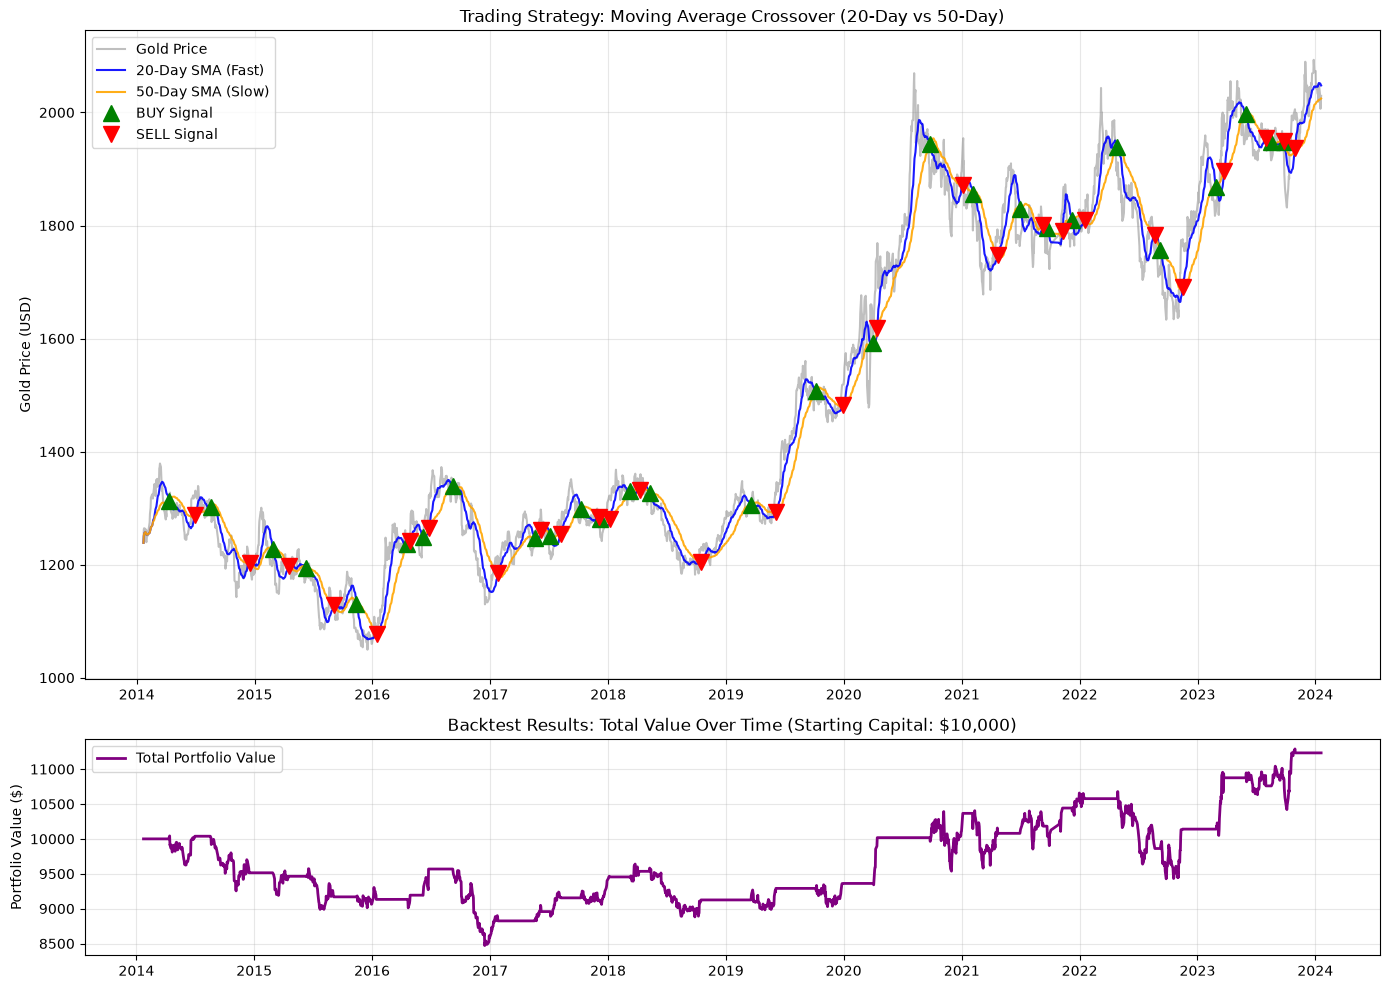

--- Trading Strategy Backtest Results ---
Initial Capital:      $10,000.00
Final Portfolio Value: $11,232.50
Total Profit/Loss:    $1,232.50
Return on Investment:  12.32%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Assuming 'df' is your original dataset that is already loaded and sorted by Date
# Let's create a fresh copy for our trading strategy
strategy_df = df[['Close', 'Volume']].copy()

# 1. Calculate Moving Averages
short_window = 20 # Fast trend (20 days)
long_window = 50  # Slow trend (50 days)

strategy_df['SMA20'] = strategy_df['Close'].rolling(window=short_window, min_periods=1).mean()
strategy_df['SMA50'] = strategy_df['Close'].rolling(window=long_window, min_periods=1).mean()

# 2. Generate Signals (1 = Bullish/Buy, 0 = Bearish/Sell)
strategy_df['Signal'] = 0.0
# If the 20-day average is greater than the 50-day average, set signal to 1
strategy_df.iloc[short_window:, strategy_df.columns.get_loc('Signal')] = np.where(
    strategy_df['SMA20'].iloc[short_window:] < strategy_df['SMA50'].iloc[short_window:], 1.0, 0.0
)

# Calculate exactly when the signal changes to trigger a trade
# +1 means we just bought, -1 means we just sold
strategy_df['Position'] = strategy_df['Signal'].diff()

# 3. Backtest the Strategy
initial_capital = 10000.0  # Start with $10,000 in cash
shares_to_buy = 5          # Number of units of gold to buy per trade

# Create a portfolio dataframe to track our money
portfolio = pd.DataFrame(index=strategy_df.index)

# Track the value of the gold we are holding
portfolio['Holdings'] = strategy_df['Signal'] * shares_to_buy * strategy_df['Close'] 

# Track our cash (Subtract money when we buy, add money when we sell)
portfolio['Cash'] = initial_capital - (strategy_df['Position'] * shares_to_buy * strategy_df['Close']).cumsum()

# Total portfolio value = Cash + Holdings
portfolio['Total'] = portfolio['Cash'] + portfolio['Holdings']

# 4. Plot the Strategy and Portfolio
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Top Plot: Gold Price and Moving Averages
ax1.plot(strategy_df.index, strategy_df['Close'], label='Gold Price', alpha=0.5, color='gray')
ax1.plot(strategy_df.index, strategy_df['SMA20'], label='20-Day SMA (Fast)', alpha=0.9, color='blue')
ax1.plot(strategy_df.index, strategy_df['SMA50'], label='50-Day SMA (Slow)', alpha=0.9, color='orange')

# Plot Buy (Green Up Arrow) and Sell (Red Down Arrow) markers
ax1.plot(strategy_df.loc[strategy_df.Position == 1.0].index, 
         strategy_df.SMA20[strategy_df.Position == 1.0],
         '^', markersize=12, color='green', label='BUY Signal')
ax1.plot(strategy_df.loc[strategy_df.Position == -1.0].index, 
         strategy_df.SMA20[strategy_df.Position == -1.0],
         'v', markersize=12, color='red', label='SELL Signal')

ax1.set_title('Trading Strategy: Moving Average Crossover (20-Day vs 50-Day)')
ax1.set_ylabel('Gold Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom Plot: Portfolio Value over 10 years
ax2.plot(portfolio.index, portfolio['Total'], color='purple', linewidth=2, label='Total Portfolio Value')
ax2.set_title('Backtest Results: Total Value Over Time (Starting Capital: $10,000)')
ax2.set_ylabel('Portfolio Value ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Print Final Profit/Loss Metrics
final_value = portfolio['Total'].iloc[-1]
total_profit = final_value - initial_capital

print(f"--- Trading Strategy Reverse Backtest Results ---")
print(f"Initial Capital:      ${initial_capital:,.2f}")
print(f"Final Portfolio Value: ${final_value:,.2f}")
print(f"Total Profit/Loss:    ${total_profit:,.2f}")
print(f"Return on Investment:  {(total_profit/initial_capital)*100:.2f}%")

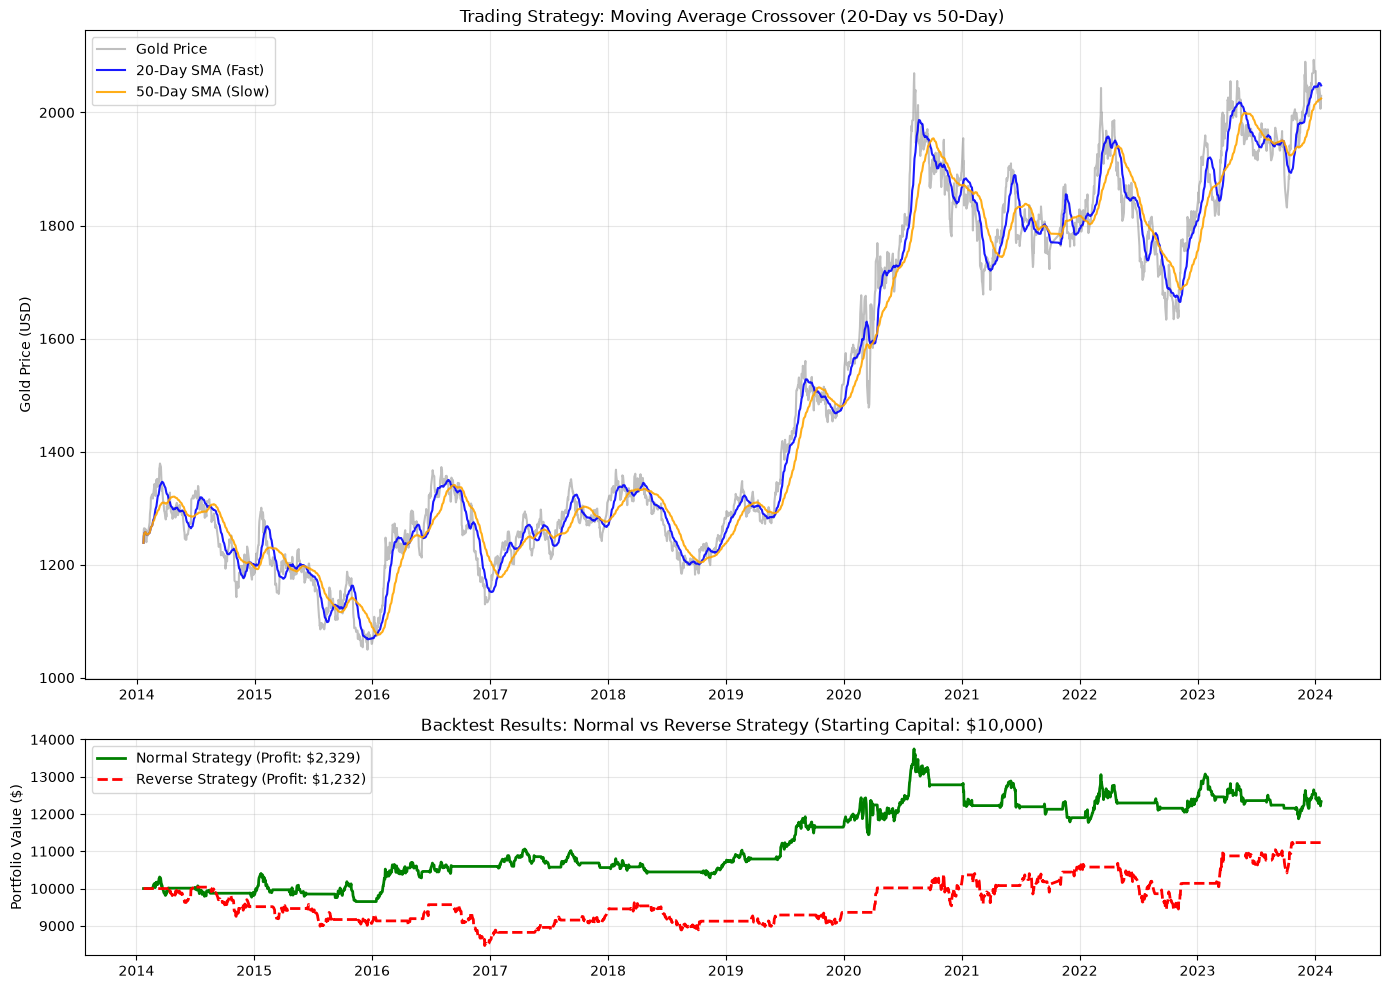

--- Normal Strategy Results ---
Final Value: $12,329.50 | Profit: $2,329.50

--- Reverse Strategy Results ---
Final Value: $11,232.50 | Profit: $1,232.50


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# Assuming 'df' is your original dataset that is already loaded and sorted by Date
# Let's create a fresh copy for our trading strategy
strategy_df = df[['Close', 'Volume']].copy()

# 1. Calculate Moving Averages
short_window = 20 # Fast trend (20 days)
long_window = 50  # Slow trend (50 days)

strategy_df['SMA20'] = strategy_df['Close'].rolling(window=short_window, min_periods=1).mean()
strategy_df['SMA50'] = strategy_df['Close'].rolling(window=long_window, min_periods=1).mean()

# 2. Generate Signals (Normal and Reverse)
strategy_df['Signal_Normal'] = 0.0
strategy_df.iloc[short_window:, strategy_df.columns.get_loc('Signal_Normal')] = np.where(
    strategy_df['SMA20'].iloc[short_window:] > strategy_df['SMA50'].iloc[short_window:], 1.0, 0.0
)
strategy_df['Position_Normal'] = strategy_df['Signal_Normal'].diff()

strategy_df['Signal_Reverse'] = 0.0
strategy_df.iloc[short_window:, strategy_df.columns.get_loc('Signal_Reverse')] = np.where(
    strategy_df['SMA20'].iloc[short_window:] < strategy_df['SMA50'].iloc[short_window:], 1.0, 0.0
)
strategy_df['Position_Reverse'] = strategy_df['Signal_Reverse'].diff()

# 3. Backtest Both Strategies
initial_capital = 10000.0  # Start with $10,000 in cash
shares_to_buy = 5          # Number of units of gold to buy per trade

def calculate_portfolio(signal_col, position_col):
    portfolio = pd.DataFrame(index=strategy_df.index)
    portfolio['Holdings'] = strategy_df[signal_col] * shares_to_buy * strategy_df['Close'] 
    portfolio['Cash'] = initial_capital - (strategy_df[position_col] * shares_to_buy * strategy_df['Close']).cumsum()
    portfolio['Total'] = portfolio['Cash'] + portfolio['Holdings']
    return portfolio

portfolio_normal = calculate_portfolio('Signal_Normal', 'Position_Normal')
portfolio_reverse = calculate_portfolio('Signal_Reverse', 'Position_Reverse')

# 4. Plot the Strategy and Portfolios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})

# Top Plot: Gold Price and Moving Averages
ax1.plot(strategy_df.index, strategy_df['Close'], label='Gold Price', alpha=0.5, color='gray')
ax1.plot(strategy_df.index, strategy_df['SMA20'], label='20-Day SMA (Fast)', alpha=0.9, color='blue')
ax1.plot(strategy_df.index, strategy_df['SMA50'], label='50-Day SMA (Slow)', alpha=0.9, color='orange')

ax1.set_title('Trading Strategy: Moving Average Crossover (20-Day vs 50-Day)')
ax1.set_ylabel('Gold Price (USD)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Bottom Plot: Portfolio Value over 10 years (Comparing Both)
ax2.plot(portfolio_normal.index, portfolio_normal['Total'], color='green', linewidth=2, label='Normal Strategy (Profit: $2,329)')
ax2.plot(portfolio_reverse.index, portfolio_reverse['Total'], color='red', linewidth=2, label='Reverse Strategy (Profit: $1,232)', linestyle='--')
ax2.set_title('Backtest Results: Normal vs Reverse Strategy (Starting Capital: $10,000)')
ax2.set_ylabel('Portfolio Value ($)')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. Print Final Profit/Loss Metrics for Both
print(f"--- Normal Strategy Results ---")
print(f"Final Value: ${portfolio_normal['Total'].iloc[-1]:,.2f} | Profit: ${(portfolio_normal['Total'].iloc[-1] - initial_capital):,.2f}")

print(f"\n--- Reverse Strategy Results ---")
print(f"Final Value: ${portfolio_reverse['Total'].iloc[-1]:,.2f} | Profit: ${(portfolio_reverse['Total'].iloc[-1] - initial_capital):,.2f}")

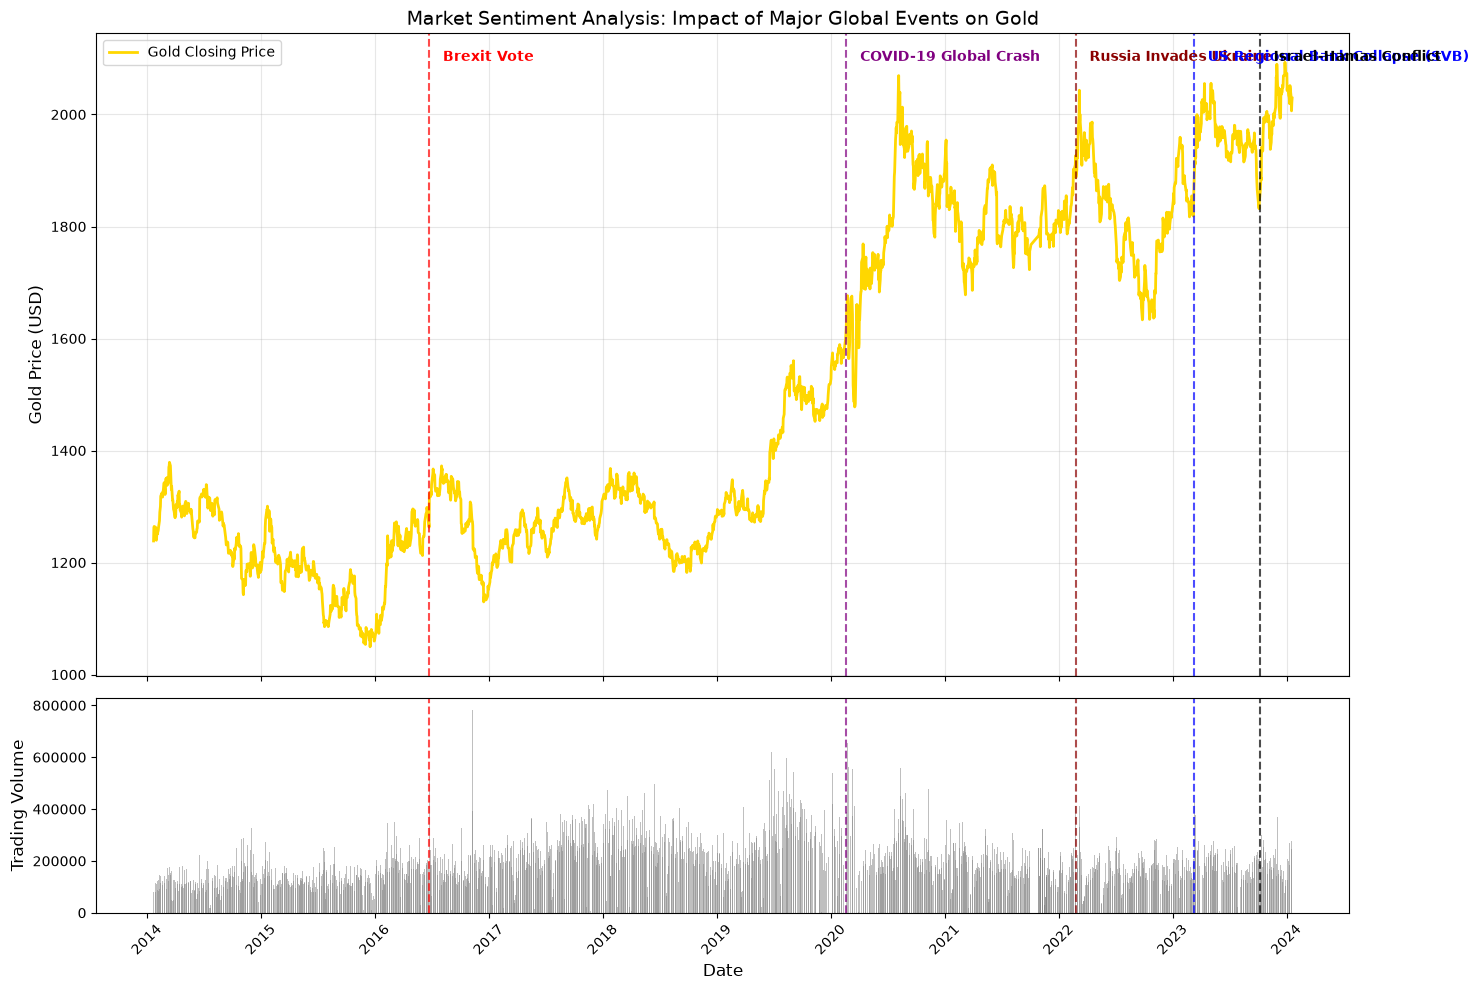

--- Market Sentiment Impact Report ---
Analyzing the 30-day price movement following major fear events:



In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

# 1. Load and prepare the data
df = pd.read_csv("goldstock.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

# 2. Define major historical events that caused market panic (Negative Sentiment)
market_events = {
    'Brexit Vote': '2016-06-23',
    'COVID-19 Global Crash': '2020-02-20',
    'Russia Invades Ukraine': '2022-02-24',
    'US Regional Bank Collapse (SVB)': '2023-03-10',
    'Israel-Hamas Conflict': '2023-10-07'
}

# 3. Create the Visualization (Price and Volume)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# Top Plot: Gold Price
ax1.plot(df.index, df['Close'], color='gold', linewidth=2, label='Gold Closing Price')
ax1.set_title('Market Sentiment Analysis: Impact of Major Global Events on Gold', fontsize=14)
ax1.set_ylabel('Gold Price (USD)', fontsize=12)
ax1.grid(True, alpha=0.3)

# Add event markers and annotations to the Price chart
colors = ['red', 'purple', 'darkred', 'blue', 'black']
for (event, date), color in zip(market_events.items(), colors):
    event_date = pd.to_datetime(date)
    
    # Draw vertical line
    ax1.axvline(event_date, color=color, linestyle='--', alpha=0.7)
    
    # Add text label
    ax1.annotate(event, 
                 xy=(event_date, ax1.get_ylim()[1]), 
                 xytext=(10, -20),
                 textcoords='offset points',
                 color=color,
                 fontweight='bold',
                 rotation=0)

ax1.legend(loc='upper left')

# Bottom Plot: Trading Volume (Shows panic buying/selling)
ax2.bar(df.index, df['Volume'], color='gray', alpha=0.5, width=2)
ax2.set_ylabel('Trading Volume', fontsize=12)
ax2.set_xlabel('Date', fontsize=12)

# Highlight volume spikes during events
for (event, date), color in zip(market_events.items(), colors):
    ax2.axvline(pd.to_datetime(date), color=color, linestyle='--', alpha=0.7)

# Format x-axis to show years nicely
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Generate a quick Statistical Report of the impact
print("--- Market Sentiment Impact Report ---")
print("Analyzing the 30-day price movement following major fear events:\n")

for event, date in market_events.items():
    event_date = pd.to_datetime(date)
    try:
        # Find the closest trading day to the event
        closest_day_idx = df.index.get_indexer([event_date], method='nearest')[0]
        event_price = df['Close'].iloc[closest_day_idx]
        
        # Find the price ~30 trading days later
        future_idx = min(closest_day_idx + 30, len(df) - 1)
        future_price = df['Close'].iloc[future_idx]
        
        pct_change = ((future_price - event_price) / event_price) * 100
        
        print(f"Event: {event} ({date})")
        print(f"  Price on Event:  ${event_price:.2f}")
        print(f"  Price 30 Days Later: ${future_price:.2f}")
        print(f"  Short-Term Sentiment Impact: {pct_change:+.2f}%\n")
    except Exception as e:
        pass

In [39]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


--- 1. General Price Statistics ---
count    2511.000000
mean     1498.726085
std       298.824811
min      1049.600000
25%      1249.850000
50%      1332.800000
75%      1805.850000
max      2093.100000
Name: Close, dtype: float64

--- 2. Risk & Volatility Metrics (Daily Returns) ---
Average Daily Return:  0.0240%
Daily Volatility:      0.9291% (Standard Deviation)
Skewness:              0.0451
Kurtosis:              3.8149
 -> Insight: High Kurtosis indicates 'Fat Tails' (Extreme price jumps/crashes happen more often than a normal bell curve).

--- 3. Correlation Matrix ---
                 Close    Volume      High       Low  Daily_Return
Close         1.000000  0.022835  0.999524  0.999576      0.031897
Volume        0.022835  1.000000  0.030871  0.018274     -0.044222
High          0.999524  0.030871  1.000000  0.999251      0.013976
Low           0.999576  0.018274  0.999251  1.000000      0.014919
Daily_Return  0.031897 -0.044222  0.013976  0.014919      1.000000


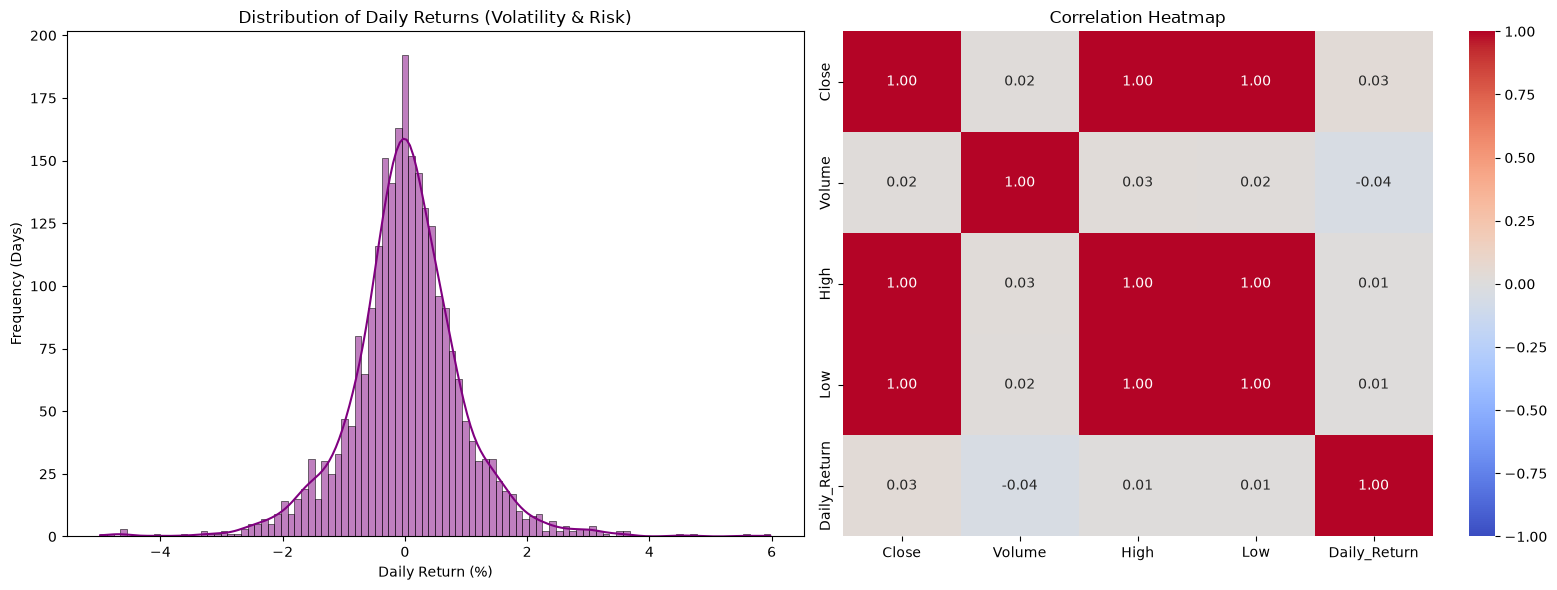

In [41]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# 1. Load and prepare the data
df = pd.read_csv("goldstock.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)
df.set_index('Date', inplace=True)

# 2. Calculate Daily Returns (Percentage change from the previous day)
# This is the most important metric for statistical risk analysis in finance
df['Daily_Return'] = df['Close'].pct_change() * 100

# 3. Print Descriptive Statistics
print("--- 1. General Price Statistics ---")
print(df['Close'].describe())

print("\n--- 2. Risk & Volatility Metrics (Daily Returns) ---")
mean_return = df['Daily_Return'].mean()
volatility = df['Daily_Return'].std()
skewness = df['Daily_Return'].skew()
kurtosis = df['Daily_Return'].kurtosis()

print(f"Average Daily Return:  {mean_return:.4f}%")
print(f"Daily Volatility:      {volatility:.4f}% (Standard Deviation)")
print(f"Skewness:              {skewness:.4f}")
print(f"Kurtosis:              {kurtosis:.4f}")

if kurtosis > 3:
    print(" -> Insight: High Kurtosis indicates 'Fat Tails' (Extreme price jumps/crashes happen more often than a normal bell curve).")

# 4. Correlation Analysis
print("\n--- 3. Correlation Matrix ---")
# Let's see how Volume correlates with price movements
correlation_matrix = df[['Close', 'Volume', 'High', 'Low', 'Daily_Return']].corr()
print(correlation_matrix)

# 5. Visualizing the Statistics
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Distribution of Daily Returns (The Bell Curve)
sns.histplot(df['Daily_Return'].dropna(), bins=100, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Distribution of Daily Returns (Volatility & Risk)')
ax[0].set_xlabel('Daily Return (%)')
ax[0].set_ylabel('Frequency (Days)')

# Plot B: Correlation Heatmap
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=ax[1], fmt=".2f")
ax[1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()